
---

# SSH 公钥生成与 GitHub 配置全流程
## 一、实验背景
SSH（Secure Shell）是一种安全的网络协议，通过**非对称加密**（公钥+私钥）实现无密码登录/认证。将本地生成的 SSH 公钥配置到 GitHub 后，可免密码提交代码、拉取仓库，避免每次操作都输入账号密码，同时提升安全性。

## 二、实验环境
| 环境        | 版本/说明                     |
|-------------|------------------------------|
| 操作系统    | Windows 10/11                |
| 工具        | Git Bash / CMD（命令提示符） |
| 目标平台    | GitHub                       |

## 三、核心概念说明
- **私钥（id_rsa）**：本地保存的密钥，相当于「数字身份证」，严禁泄露；
- **公钥（id_rsa.pub）**：可公开的密钥，配置到 GitHub 等平台，用于身份验证；
- **密钥对**：私钥和公钥成对生成，仅匹配的密钥对才能通过认证。

## 四、操作全流程
### 步骤1：打开终端工具
- 打开「CMD 命令提示符」（Win+R 输入 `cmd` 回车）。

### 步骤2：生成 SSH 密钥对
1. 执行以下命令生成密钥（替换为自己的 GitHub 绑定邮箱）：
   ```bash
   ssh-keygen -t rsa -b 4096 -C "your_email@github.com"
   ```
   参数说明：
   - `-t rsa`：指定密钥类型为 RSA（主流加密算法）；
   - `-b 4096`：设置密钥长度为 4096 位（更高安全性）；
   - `-C`：添加注释（邮箱），用于区分不同密钥。

2. 命令执行后，按提示依次操作（全程回车即可）：
   - 提示 `Enter file in which to save the key`：回车，使用默认路径（`C:\Users\16858\.ssh\id_rsa`）；
   - 提示 `Enter passphrase (empty for no passphrase)`：设置密码，回车；
   - 提示 `Enter same passphrase again`：确认密码。

![生成SSH密钥](img_1.png)

### 步骤3：查看并复制本地公钥
#### CMD 中操作
```cmd
# 进入 .ssh 目录
cd %USERPROFILE%\.ssh
# 查看公钥内容
type id_rsa.pub
# 复制公钥到剪贴板（一键操作）
type id_rsa.pub | clip
```
![查看并复制密钥](img_2.png)

### 步骤4：配置公钥到 GitHub
1. 登录 GitHub 账号，点击右上角头像 →「Settings」（设置）；
2. 左侧菜单栏选择「SSH and GPG keys」；
3. 点击「New SSH key」（新建 SSH 密钥）；
4. 填写配置项：
   - Title：自定义名称（如「Windows 本机」）；
   - Key：粘贴步骤3中复制的公钥内容；
5. 点击「Add SSH key」（添加），若弹出密码验证，输入 GitHub 账号密码确认。

### 步骤5：验证配置是否生效
1. 回到 Git Bash/CMD，执行验证命令：
   ```bash
   ssh -T git@github.com
   ```
2. 首次执行会提示「Are you sure you want to continue connecting」，输入 `yes` 回车；
3. 若输出以下内容，说明配置成功：
   ```
   Hi [你的 GitHub 用户名]! You've successfully authenticated, but GitHub does not provide shell access.
   ```

### 总结
1. 核心流程：生成密钥对 → 复制公钥 → 配置到 GitHub → 验证生效，全程密钥仅保存在本地，公钥按需公开；
2. 关键命令：`ssh-keygen`（生成密钥）、`ssh -T git@github.com`（验证配置）；

---
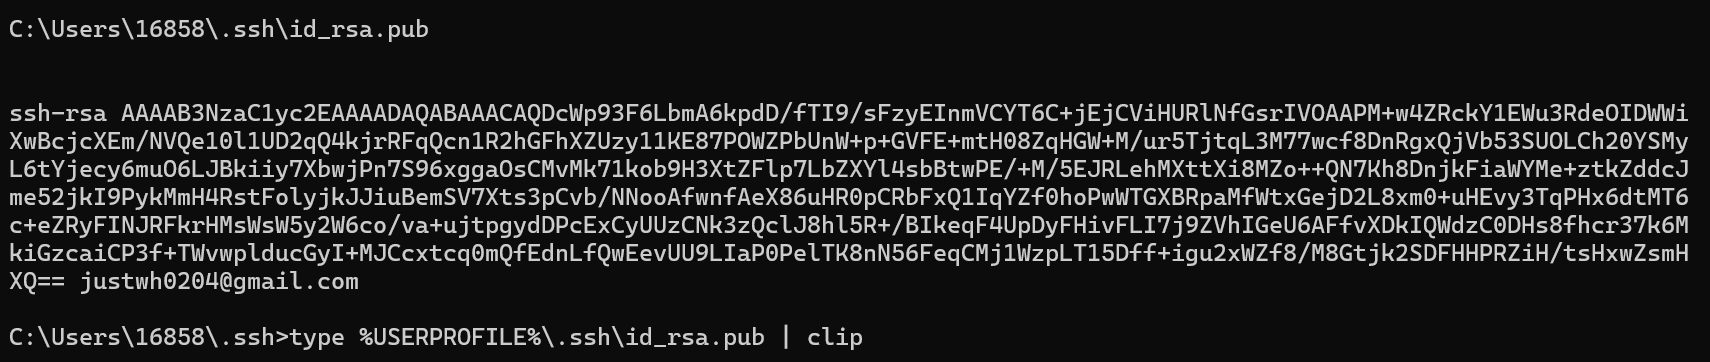